# DCT1401 - Inteligência Artificial (UFRN)
## Percepções e Análise para o Problema de Classificação
**Aluno:** Wallison Valdemiro Silvino Dias  
**Matrícula:** 20250023771  
**Target:** `Outdoor_Activity_Recommendation` (Recomendação de Atividade ao Ar Livre)  
**Dataset:** Greek Urban Air Quality & Health Impact Dataset (2020-2024)

---
### Objetivos Desta Etapa
1. Justificação detalhada da seleção de `Outdoor_Activity_Recommendation` como variável alvo para classificação.
2. Avaliação da distribuição e balanceamento das 4 classes de recomendação sanitária.
3. Análise estatística de poder discriminante das features (testes ANOVA e Chi-Quadrado).
4. Avaliação de importância de atributos com modelo supervisionado baseline.
5. Formulação de recomendações de algoritmos, métricas adequadas e mitigação de desafios.

In [1]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from src import data_loader, visualization

visualization.set_plot_style()
print("Módulos carregados com sucesso.")

Módulos carregados com sucesso.


### 1. Identificação e Justificativa da Variável Alvo
Optou-se por **`Outdoor_Activity_Recommendation`** pelas seguintes razões:
- **Acionabilidade em Saúde Pública:** Fornece um direcionamento direto ao cidadão (se é seguro realizar esportes ao ar livre, se grupos de risco devem se resguardar ou se toda a população deve evitar exposição).
- **Equilíbrio Entre Classes:** Ao contrário do `AQI_Category`, cuja classe "Hazardous" representa menos de $0.83\%$ do dataset gerando desbalanceamento severo, as 4 classes de recomendação apresentam frequência substancial em todas as categorias (de $17.3\%$ a $39.6\%$).

In [2]:
# Carregamento do dataset original para análise das classes
raw_df = data_loader.load_raw_data(sample_frac=0.2)

# Distribuição das 4 categorias
class_counts = raw_df["Outdoor_Activity_Recommendation"].value_counts()
class_pcts = raw_df["Outdoor_Activity_Recommendation"].value_counts(normalize=True) * 100

display(pd.DataFrame({"Contagem (Amostra)": class_counts, "Percentual (%)": class_pcts.round(2)}))

,Contagem (Amostra),Percentual (%)
Outdoor_Activity_Recommendation,,
Sensitive groups limit outdoor activity,36148,39.89
Reduce prolonged outdoor activity,21120,23.31
All activities safe,17676,19.51
Avoid outdoor activity,15675,17.30


### 2. Relação Entre Features e Classes (Análise Bivariada)
Avaliamos visualmente como a concentração de poluentes se distribui em cada uma das 4 faixas de recomendação sanitária.

C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\src\visualization.py:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\src\visualization.py:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\src\visualization.py:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Gráfico salvo em: C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\reports\figures\classification_features_boxplot.png


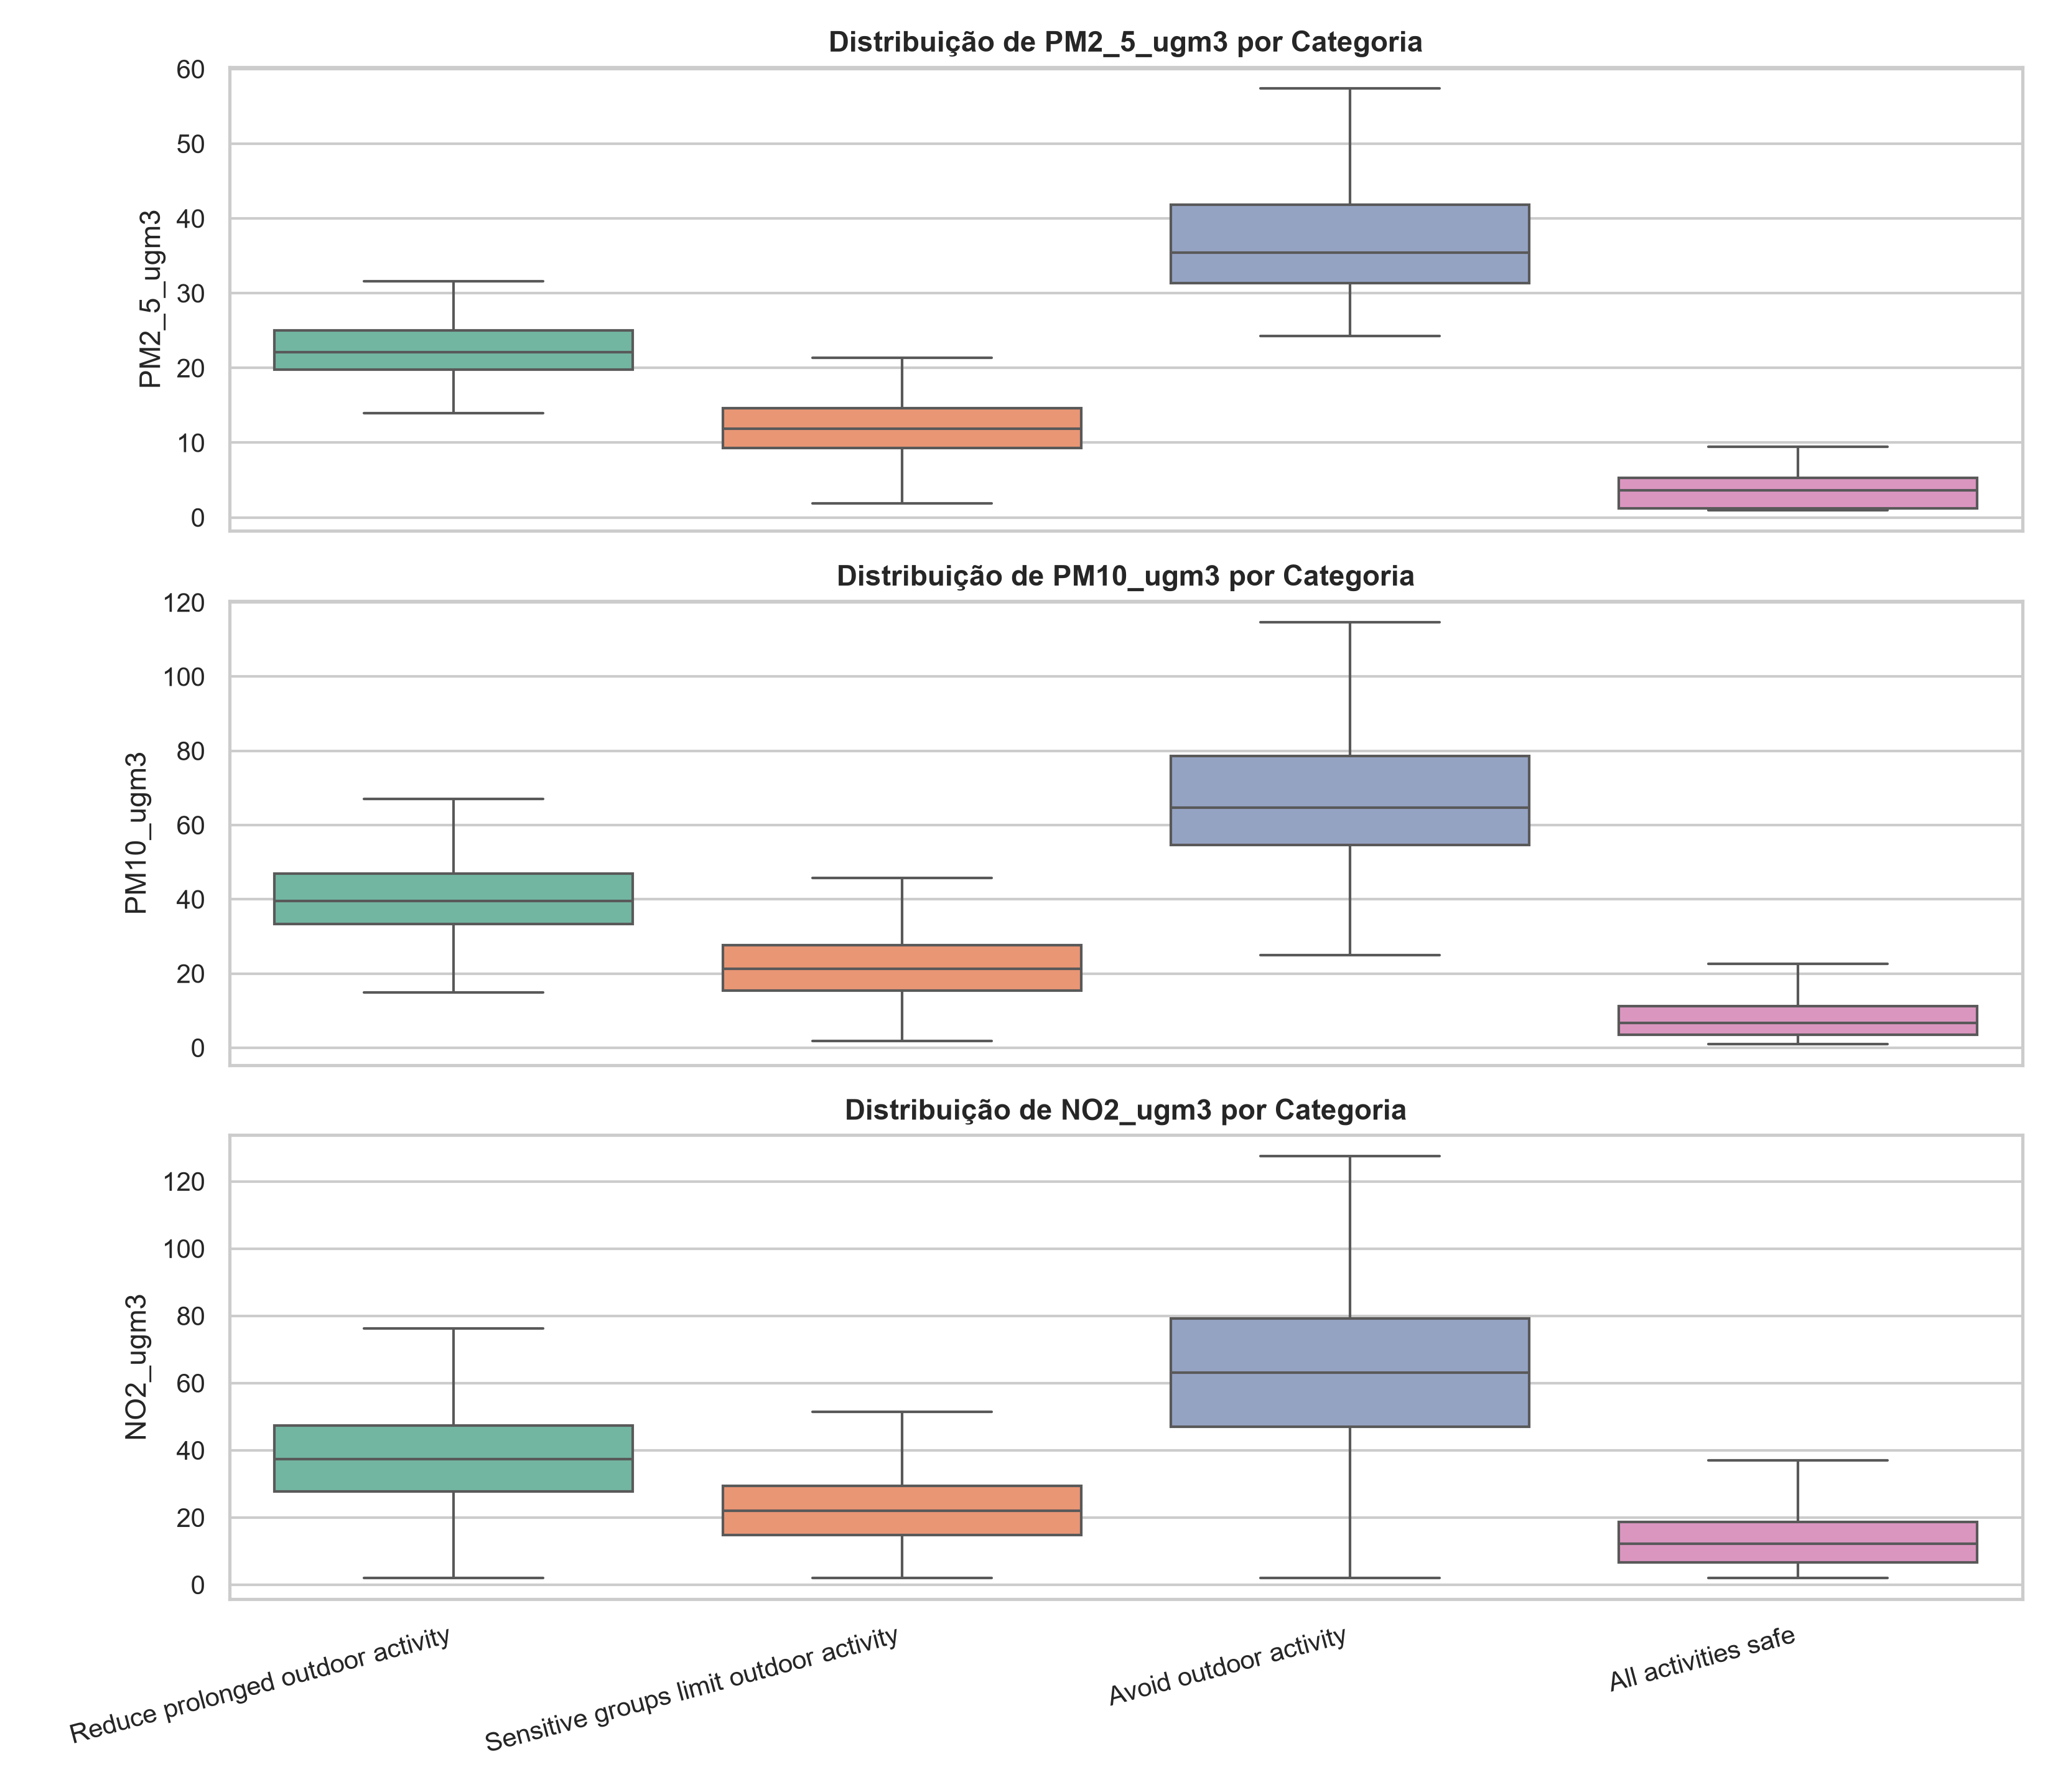

In [3]:
# Boxplots das features principais por classe de recomendação
fig_box_path = visualization.plot_features_by_class(
    raw_df,
    features=["PM2_5_ugm3", "PM10_ugm3", "NO2_ugm3"],
    class_col="Outdoor_Activity_Recommendation",
    save_name="classification_features_boxplot.png",
)
print(f"Gráfico salvo em: {fig_box_path}")
from IPython.display import Image
Image(filename=str(fig_box_path))

### 3. Testes Estatísticos de Hipótese (Poder Preditivo)
- **ANOVA One-Way:** Testa se há diferença estatisticamente significativa nas médias das variáveis contínuas entre as 4 classes de recomendação.
- **Qui-Quadrado ($\chi^2$):** Testa independência entre variáveis categóricas binárias (`Wildfire_Smoke_Event`, `Saharan_Dust_Event`) e as classes de recomendação.

In [4]:
# 1. ANOVA One-Way para features contínuas
continuous_feats = ["PM2_5_ugm3", "PM10_ugm3", "NO2_ugm3", "Traffic_Density_Index", "Temperature_C"]
anova_results = []

for feat in continuous_feats:
    groups = [group[feat].dropna().values for _, group in raw_df.groupby("Outdoor_Activity_Recommendation")]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({"Feature": feat, "Estatística F": f_stat, "p-valor": p_val})

anova_df = pd.DataFrame(anova_results).sort_values(by="Estatística F", ascending=False)
display(anova_df.round(4))

,Feature,Estatística F,p-valor
0,PM2_5_ugm3,124014.7739,0.0
1,PM10_ugm3,80172.7447,0.0
2,NO2_ugm3,41161.1154,0.0
3,Traffic_Density_Index,38588.5559,0.0
4,Temperature_C,291.1657,0.0


In [5]:
# 2. Teste Qui-Quadrado para eventos binários
binary_feats = ["Wildfire_Smoke_Event", "Saharan_Dust_Event", "Heating_Season"]
chi2_results = []

for feat in binary_feats:
    contingency = pd.crosstab(raw_df[feat], raw_df["Outdoor_Activity_Recommendation"])
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
    chi2_results.append({"Evento": feat, "Qui-Quadrado (χ²)": chi2, "p-valor": p_val, "Graus de Liberdade": dof})

chi2_df = pd.DataFrame(chi2_results).sort_values(by="Qui-Quadrado (χ²)", ascending=False)
display(chi2_df.round(4))

,Evento,Qui-Quadrado (χ²),p-valor,Graus de Liberdade
0,Wildfire_Smoke_Event,1337.4707,0.0,3
1,Saharan_Dust_Event,1276.4677,0.0,3
2,Heating_Season,737.6763,0.0,3


### 4. Modelo Baseline de Classificação (Random Forest)
Treinamos um classificador Random Forest no dataset processado de classificação para mensurar o poder preditivo conjunto e extrair a importância das variáveis.

Relatório de Classificação do Modelo Baseline:
                  precision    recall  f1-score   support

            Safe       0.97      0.93      0.95      1958
 Sensitive Limit       0.94      0.97      0.95      3992
Reduce Prolonged       0.94      0.94      0.94      2358
           Avoid       0.98      0.96      0.97      1692

        accuracy                           0.95     10000
       macro avg       0.96      0.95      0.95     10000
    weighted avg       0.95      0.95      0.95     10000



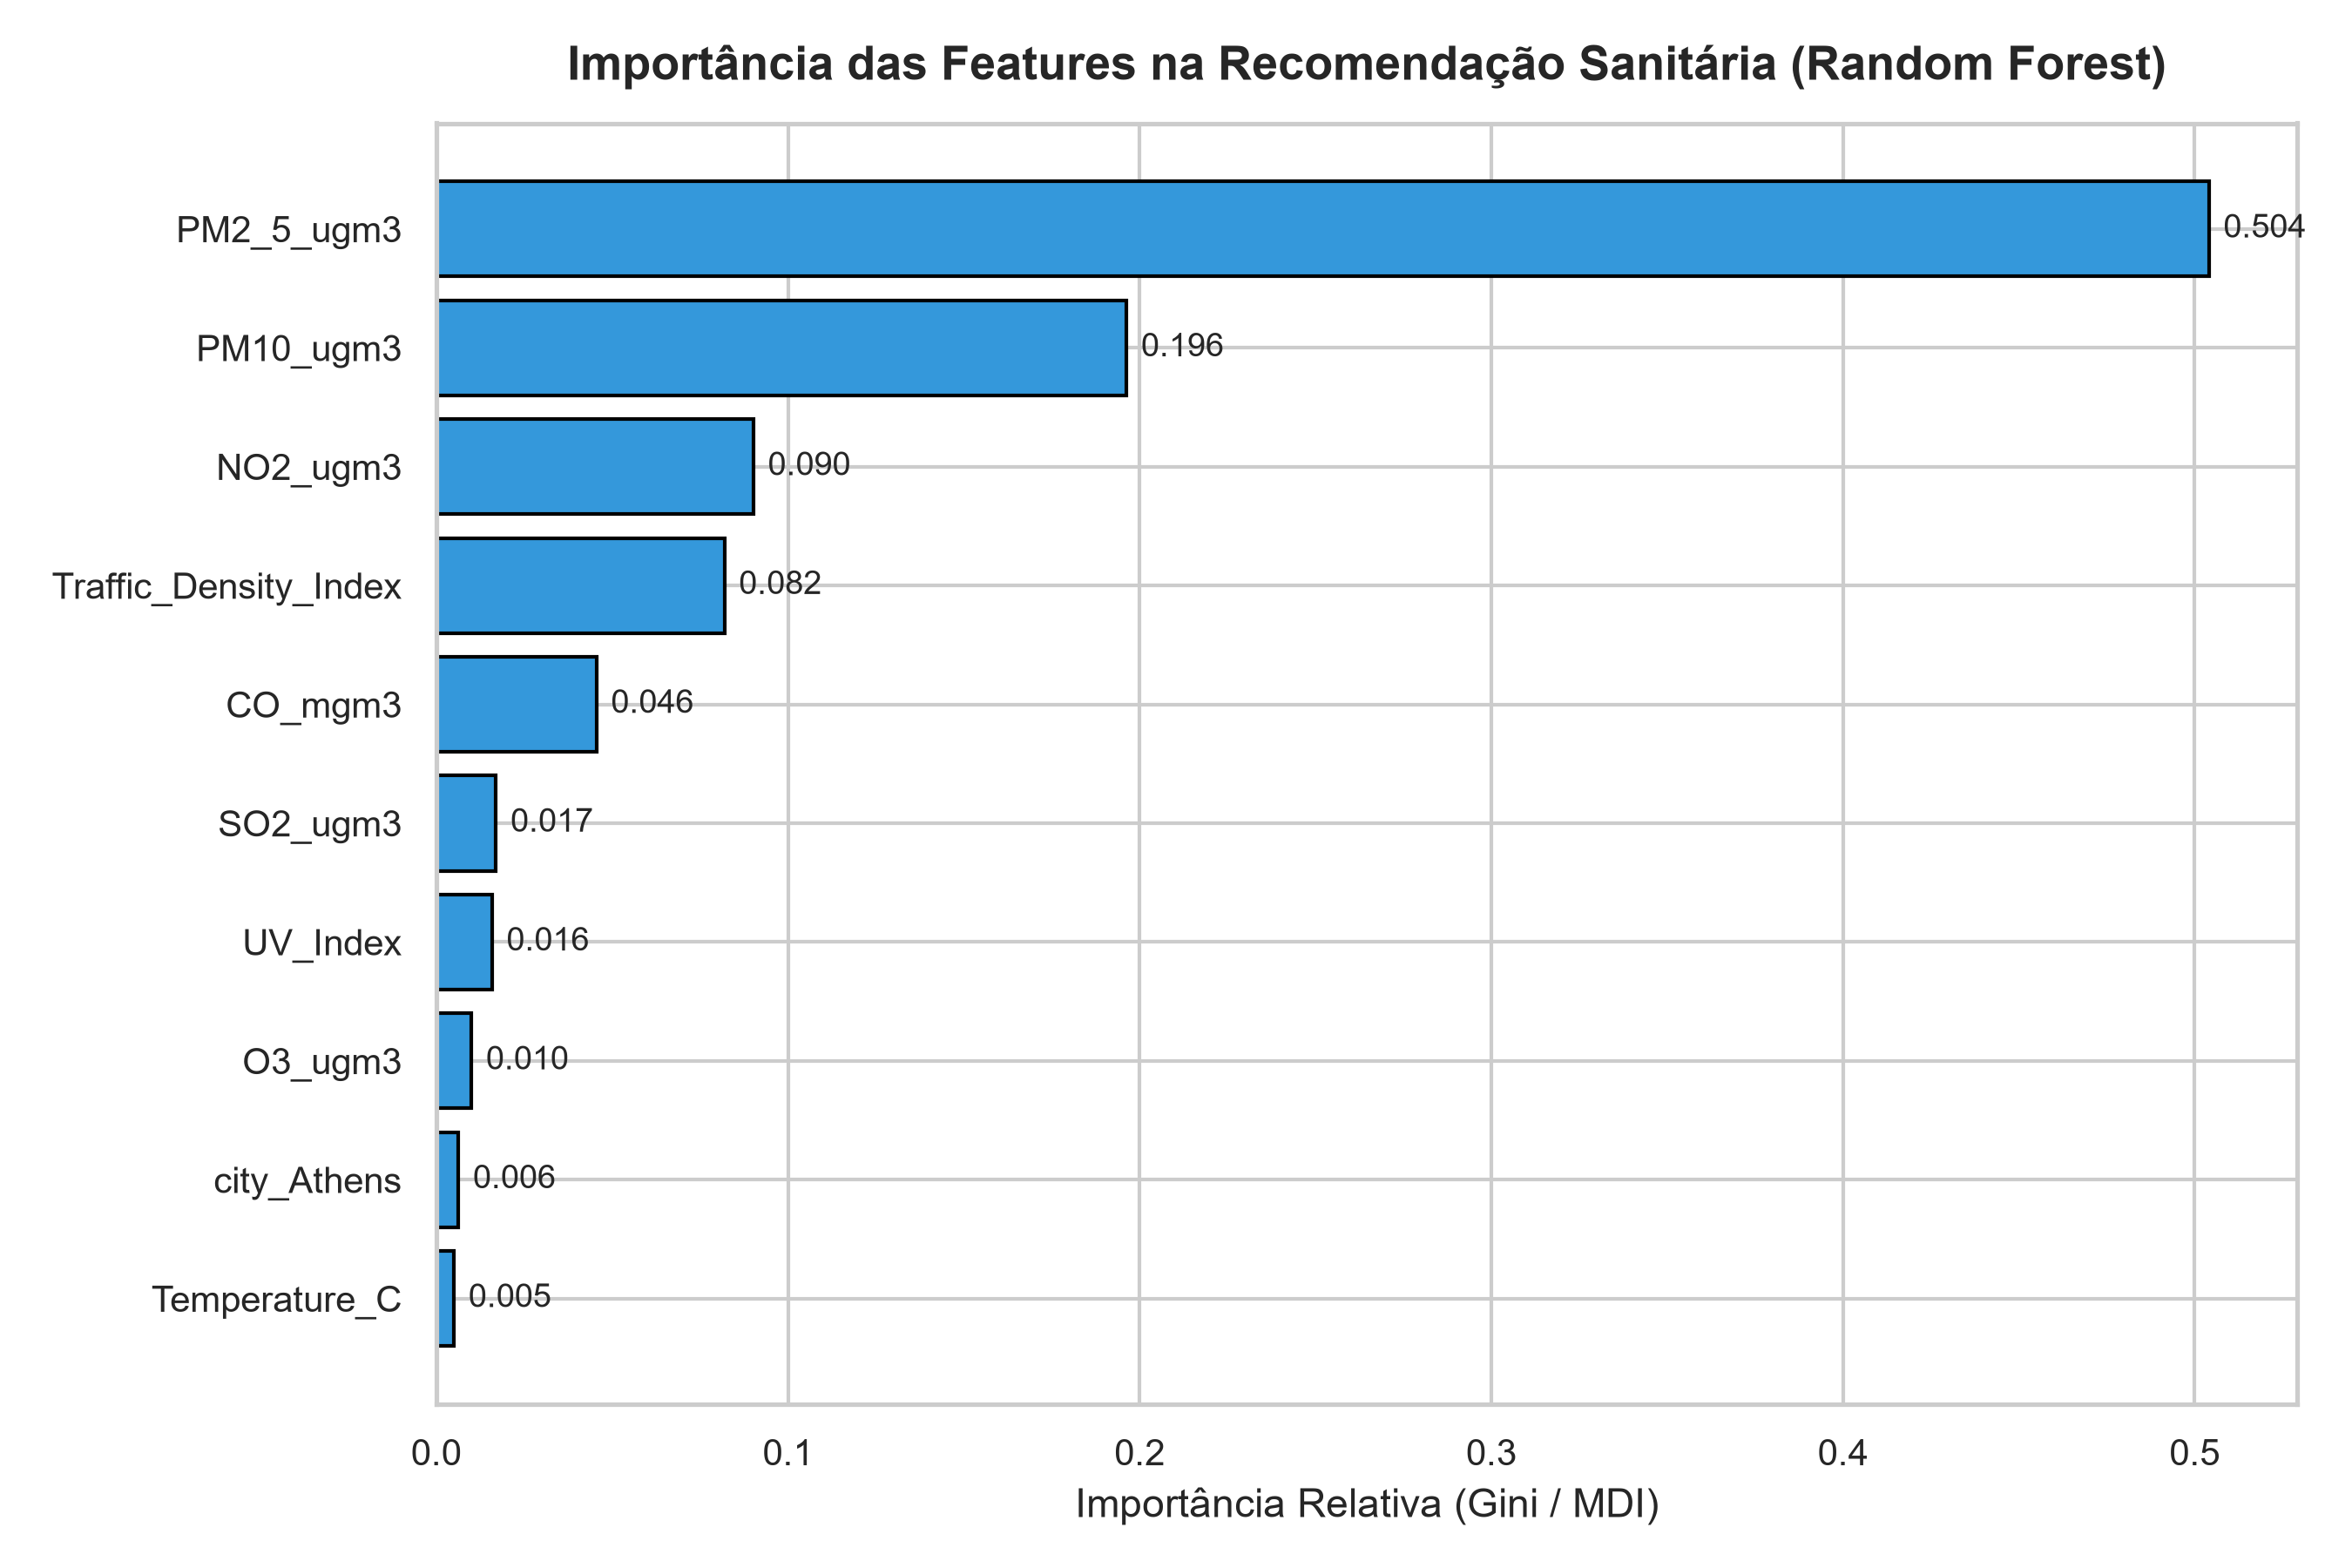

In [6]:
# Carrega dados de classificação
clf_df = data_loader.load_classification_data()

X = clf_df.drop(columns=["target_class"])
y = clf_df["target_class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train.iloc[:40000], y_train.iloc[:40000])

y_pred = rf_clf.predict(X_test.iloc[:10000])
target_names = [
    "Safe",
    "Sensitive Limit",
    "Reduce Prolonged",
    "Avoid",
]
print("Relatório de Classificação do Modelo Baseline:")
print(classification_report(y_test.iloc[:10000], y_pred, target_names=target_names))

# Gráfico de importância
fig_clf_imp = visualization.plot_feature_importance(
    X.columns.tolist(),
    rf_clf.feature_importances_,
    title="Importância das Features na Recomendação Sanitária (Random Forest)",
    save_name="classification_feature_importance.png",
    top_n=10,
)
Image(filename=str(fig_clf_imp))

### 5. Percepções e Recomendações para Modelagem
1. **Principais Features Recomendadas:**
   - $PM_{2.5}$ e $PM_{10}$: Demonstraram o maior valor na estatística F do teste ANOVA e a maior importância relativa, pois as partículas finas inaláveis são os critérios biológicos centrais que definem restrição de atividade.
   - $NO_2$ e $CO$: Poluentes que discriminam bem as faixas de recomendação nos centros urbanos.
   - Eventos climáticos (`Wildfire_Smoke_Event`): Apresentaram dependência significativa com $\chi^2$ elevado, correlacionando-se diretamente com a classe de maior severidade (*Avoid outdoor activity*).

2. **Possíveis Desafios:**
   - **Natureza Ordinal das Classes:** As 4 categorias possuem ordenação intrínseca de gravidade sanitária. Modelos de classificação multiclasse padrão tratam as classes como nominais independentes, perdendo a noção de que errar entre "Safe" e "Avoid" é muito mais grave do que errar entre "Safe" e "Sensitive Limit".
   - **Recomendação:** Avaliar modelos de **Regressão Ordinal** (ex: *Ordinal Logistic Regression*) ou penalização diferencial na matriz de custos.

3. **Sugestões de Algoritmos:**
   - **Random Forest Classifier & Gradient Boosting (LightGBM/XGBoost):** Apresentam excelente separabilidade e curvas de calibração de probabilidade confiáveis.
   - **Regressão Logística Multinomial com Regularização L2:** Oferece baseline probabilístico altamente interpretável.
   - **K-Nearest Neighbors (KNN):** Útil para identificar estações e condições atmosféricas análogas no espaço vetorial padronizado.